hledám podobné látky podle struktury protože předpokládám že budou podobně fungovat
popisuje pouze 2D strukturu

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import AllChem, DataStructs

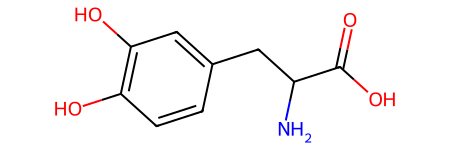

In [4]:
# vyzualizace chemické struktury ze smiles
smiles_levodopa = "C1=CC(=C(C=C1CC(C(=O)O)N)O)O"
mol_levodopa = Chem.MolFromSmiles(smiles_levodopa)

mol_levodopa

In [8]:
# načítám dostupné látky ze souboru a tvořím jejich strukturu pro pozdější porovnání
df = pd.read_csv('compounds.csv', sep=';')

display(df.head())

smiles_list = df['smiles'].tolist()

mols = [Chem.MolFromSmiles(s) for s in smiles_list]


print(f"\nÚspěšně načteno {len(mols)} molekul k analýze.")

,name,smiles,pubmed
0,"Ethyl 2-amino-3-(3,4-dihydroxyphenyl)propanoate",CCOC(=O)C(CC1=CC(=C(C=C1)O)O)N,https://pubchem.ncbi.nlm.nih.gov/compound/1179...
1,"(S)-Methyl 2-amino-3-(3,4-dihydroxyphenyl)prop...",COC(=O)C(CC1=CC(=C(C=C1)O)O)N.Cl,https://pubchem.ncbi.nlm.nih.gov/compound/1013...
2,Etilevodopa,CCOC(=O)C(CC1=CC(=C(C=C1)O)O)N,https://pubchem.ncbi.nlm.nih.gov/compound/170345
3,Foslevodopa,C1=CC(=C(C=C1CC(C(=O)O)N)O)OP(=O)(O)O,https://pubchem.ncbi.nlm.nih.gov/compound/127766
4,Melevodopa,COC(=O)C(CC1=CC(=C(C=C1)O)O)N,https://pubchem.ncbi.nlm.nih.gov/compound/23497



Úspěšně načteno 8 molekul k analýze.


In [9]:
# převede smiles na jedničky a nuly a velikost radius na kolik sousedů koukám a slouží k vytvoření toho řetezce jedniček a nul
radius = 2
n_bits = 2048

mol_levodopa = Chem.MolFromSmiles("C1=CC(=C(C=C1CC(C(=O)O)N)O)O")
ref_fp = AllChem.GetMorganFingerprintAsBitVect(mol_levodopa, radius, nBits=n_bits)

mols_fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=n_bits) for m in mols]

similarities = [DataStructs.TanimotoSimilarity(ref_fp, fp) for fp in mols_fps]

df['tanimoto_similarity'] = similarities

print("Výpočet úspěšně dokončen!")
display(df[['name', 'tanimoto_similarity']].head(6))

Výpočet úspěšně dokončen!


[09:48:10] DEPRECATION WARNING: please use MorganGenerator
[09:48:10] DEPRECATION WARNING: please use MorganGenerator
[09:48:10] DEPRECATION WARNING: please use MorganGenerator
[09:48:10] DEPRECATION WARNING: please use MorganGenerator
[09:48:10] DEPRECATION WARNING: please use MorganGenerator
[09:48:10] DEPRECATION WARNING: please use MorganGenerator
[09:48:10] DEPRECATION WARNING: please use MorganGenerator
[09:48:10] DEPRECATION WARNING: please use MorganGenerator
[09:48:10] DEPRECATION WARNING: please use MorganGenerator


,name,tanimoto_similarity
0,"Ethyl 2-amino-3-(3,4-dihydroxyphenyl)propanoate",0.638889
1,"(S)-Methyl 2-amino-3-(3,4-dihydroxyphenyl)prop...",0.638889
2,Etilevodopa,0.638889
3,Foslevodopa,0.615385
4,Melevodopa,0.657143
5,L-DOPA (sodium),0.964286


--- TOP 3 NEJPODOBNĚJŠÍ MOLEKULY ---


,name,smiles,tanimoto_similarity
5,L-DOPA (sodium),C1=CC(=C(C=C1CC(C(=O)O)N)O)O.[Na],0.964286
6,"Tyrosine, 3-hydroxy-O-methyl-",COC1=C(C=C(C=C1)CC(C(=O)O)N)O,0.666667
7,3-Methoxytyrosine,COC1=C(C=CC(=C1)CC(C(=O)O)N)O,0.666667


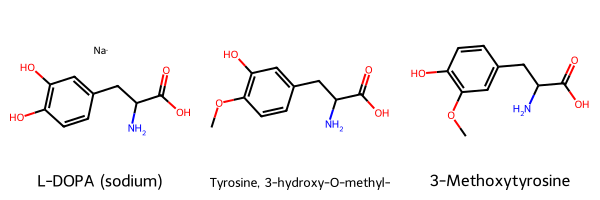

In [ ]:
# vyberu nejlepší 3 a zobrazím je
df_sorted = df.sort_values(by='tanimoto_similarity', ascending=False)

top_3 = df_sorted.head(3)

print("--- TOP 3 NEJPODOBNĚJŠÍ MOLEKULY ---")
display(top_3[['name', 'smiles', 'tanimoto_similarity']])

top_mols = [Chem.MolFromSmiles(s) for s in top_3['smiles']]
img = Draw.MolsToGridImage(top_mols, legends=top_3['name'].tolist(), molsPerRow=3)
display(img)